# Figure 3 Reproduction

This notebook reproduces Figure 3 from the paper, plotting model latencies (UDA update, prediction, and finetuning) from a pre-processed CSV file. The plot shows performance on both CPU and GPU, with marker size indicating the model's parameter count.

In [17]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.ticker import FuncFormatter, LogLocator, NullFormatter, FixedLocator
from matplotlib.legend import Legend
import matplotlib.ticker

# --- Helpers ---
def cm2inch(*dims):
    """Converts dimensions from centimeters to inches."""
    inch_per_cm = 2.54
    if isinstance(dims[0], (list, tuple)):
        return tuple(d / inch_per_cm for d in dims[0])
    return tuple(d / inch_per_cm for d in dims)

# --- Configuration ---
TARGET_DATASET = "Yang2025"
GLOBAL_FONTSIZE = 7
LEGEND_FONTSIZE = 6.5
PANEL_LABEL_FONTSIZE = 10

param_counts_map = {
    "ShallowConvNet": 121_200,
    "EEGNetv4": 12_700,
    "ATCNet": 114_700,
    "DeepConvNet": 321_500,
}

device_marker_color = {"cpu": "#7f7f7f", "cuda": "#2ca02c"}
model_size_marker_shape = "o"

plots_config = [
    ("tta_update_latency_ms_median", "UDA update latency\n(ms/trial)"),
    ("pred_latency_ms_median", "Prediction latency\n(ms/trial)"),
    ("finetune_epoch_ms_median", "Finetuning latency\n(ms/finetuning step)"),
]

# --- Style Configuration ---
# Using fallback styles directly to ensure reproducibility.
rc_params = {
    "font.size": GLOBAL_FONTSIZE, "legend.fontsize": LEGEND_FONTSIZE,
    "axes.titlesize": GLOBAL_FONTSIZE, "axes.labelsize": GLOBAL_FONTSIZE,
    "xtick.labelsize": GLOBAL_FONTSIZE, "ytick.labelsize": GLOBAL_FONTSIZE,
    "font.weight": "normal",
    "axes.labelweight": "normal",
    "axes.titleweight": "normal",
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
    "savefig.format": "pdf", "savefig.bbox": "tight", "savefig.pad_inches": 0.05,
    "pdf.fonttype": 42, "ps.fonttype": 42,
}

In [18]:
# --- Data Loading and Preparation ---
# Create a directory for the data if it doesn't exist.
data_dir = Path("figure_data")
data_dir.mkdir(exist_ok=True)

COLLATED_CSV_PATH = data_dir / f"figure3_latency_summary_{TARGET_DATASET}.csv"

# If the CSV doesn't exist, create a dummy one for demonstration purposes.
# This ensures the notebook can run even without the original data file.
if not COLLATED_CSV_PATH.exists():
    print(f"Warning: {COLLATED_CSV_PATH} not found. Creating a dummy CSV for demonstration.")
    dummy_tta_latencies = []
    base_tta = [
        np.random.uniform(1,20), np.random.uniform(1,20), np.random.uniform(0.5,5), np.random.uniform(0.5,5),
        np.random.uniform(1,15), np.random.uniform(1,15), 2.8, 2.85,
    ]
    for _ in range(3):
        dummy_tta_latencies.extend(base_tta)

    models_cycle = ['ShallowConvNet', 'EEGNetv4', 'ATCNet', 'DeepConvNet']
    devices_cycle = ['cpu', 'cuda']
    num_entries = len(dummy_tta_latencies) // (len(models_cycle) * len(devices_cycle))

    dummy_models, dummy_devices = [], []
    for _ in range(num_entries):
        for model in models_cycle:
            for device in devices_cycle:
                dummy_models.append(model)
                dummy_devices.append(device)

    if len(dummy_tta_latencies) != len(dummy_models):
        dummy_tta_latencies = (dummy_tta_latencies * (len(dummy_models) // len(dummy_tta_latencies) + 1))[:len(dummy_models)]

    dummy_data = {
        'model': dummy_models,
        'dataset': [TARGET_DATASET] * len(dummy_models),
        'device': dummy_devices,
        'tta_update_latency_ms_median': dummy_tta_latencies,
        'pred_latency_ms_median': np.random.uniform(0.01, 100, len(dummy_models)),
        'finetune_epoch_ms_median': np.random.uniform(1, 2000, len(dummy_models)),
        'total_params': [param_counts_map.get(m, 0) for m in dummy_models]
    }
    df_full = pd.DataFrame(dummy_data).groupby(['model', 'dataset', 'device']).median().reset_index()
    df_full['total_params'] = df_full['model'].map(param_counts_map)
    df_full.to_csv(COLLATED_CSV_PATH, index=False)
    print(f"Dummy CSV created at {COLLATED_CSV_PATH}")

# Load the data
try:
    df_full = pd.read_csv(COLLATED_CSV_PATH)
    print(f"Successfully loaded data from: {COLLATED_CSV_PATH}")
except (FileNotFoundError, pd.errors.EmptyDataError) as e:
    print(f"Error reading {COLLATED_CSV_PATH}: {e}. Please ensure the file exists and is not empty.")
    df_full = pd.DataFrame() # Create empty dataframe to avoid further errors

# Prepare the final dataframe for plotting
if not df_full.empty:
    TARGET_MODELS = ["ShallowConvNet", "EEGNetv4", "ATCNet", "DeepConvNet"]
    df = df_full[(df_full["model"].isin(TARGET_MODELS)) & (df_full["dataset"] == TARGET_DATASET)].copy()
    df.loc[:, "param_count"] = df["model"].map(param_counts_map)
    df["param_count"].fillna(df.get("total_params", 10000), inplace=True)
    print(f"Data prepared for plotting. Shape: {df.shape}")
else:
    df = pd.DataFrame()

Successfully loaded data from: figure_data/figure3_latency_summary_Yang2025.csv
Data prepared for plotting. Shape: (8, 21)


/tmp/ipykernel_1374416/781916538.py:61: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["param_count"].fillna(df.get("total_params", 10000), inplace=True)


/tmp/ipykernel_1374416/76666984.py:82: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Rectangle((0, 0), 1, 1, color=c, edgecolor='black', linewidth=0.5)


Saved plot to: plots/figure3_reproduction.pdf


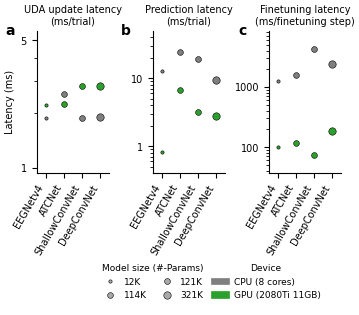

In [19]:
# --- Plotting ---
if not df.empty:
    # Apply the style configuration using a context manager
    with plt.rc_context(rc_params):
        # Create a directory for the plots
        output_plot_dir = Path("plots")
        output_plot_dir.mkdir(exist_ok=True)

        # Set figure size: 90mm width, and adjusted height for legend
        fig, axes = plt.subplots(nrows=1, ncols=3, sharey=False, figsize=cm2inch(9, 9))
        param_marker_scale_factor = 0.050

        for i, (metric_col, y_label_base_title) in enumerate(plots_config):
            ax = axes[i]
            ax.set_title(y_label_base_title, pad=5)
            panel_label = chr(ord('a') + i)
            ax.text(-0.3, 1.05, panel_label, transform=ax.transAxes,
                    fontsize=PANEL_LABEL_FONTSIZE, fontweight='bold', va='top', ha='right')

            if metric_col not in df.columns or df.dropna(subset=[metric_col]).empty:
                ax.text(0.5, 0.5, "No Data", ha='center', va='center', transform=ax.transAxes)
                continue

            metric_df_subplot_full = df.dropna(subset=[metric_col])
            unique_models_in_subplot = sorted(metric_df_subplot_full["model"].unique())
            model_param_counts_for_sort = metric_df_subplot_full[['model', 'param_count']].drop_duplicates().set_index('model')['param_count']
            subplot_model_order = sorted(unique_models_in_subplot, key=lambda m: model_param_counts_for_sort.get(m, float('inf')))

            ax.set_yscale("log")
            all_data_for_metric = metric_df_subplot_full[metric_col]
            ax.set_ylim(max(all_data_for_metric.min() * 0.5, 1e-4), all_data_for_metric.max() * 2)

            ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.2f}" if x < 1 else f"{int(round(x))}"))
            
            # Custom tick handling for the first panel
            if i == 0:
                auto_locator = LogLocator(base=10.0, numticks=10)
                auto_ticks = auto_locator.tick_values(ax.get_ylim()[0], ax.get_ylim()[1])
                
                custom_ticks = list(auto_ticks)
                if 5 >= ax.get_ylim()[0] and 5 <= ax.get_ylim()[1] and 5 not in custom_ticks:
                    custom_ticks.append(5)
                
                custom_ticks = sorted(custom_ticks)
                ax.yaxis.set_major_locator(FixedLocator(custom_ticks))
            else:
                ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
                
            ax.yaxis.set_minor_formatter(NullFormatter())
            if i == 0:
                ax.set_ylabel("Latency (ms)")

            for model_idx, model_name in enumerate(subplot_model_order):
                model_subplot_data = metric_df_subplot_full[metric_df_subplot_full["model"] == model_name]
                for device in ["cpu", "cuda"]:
                    device_data = model_subplot_data[model_subplot_data["device"] == device]
                    if not device_data.empty and pd.notna(device_data[metric_col].iloc[0]):
                        latency_val = device_data[metric_col].iloc[0]
                        params = device_data["param_count"].iloc[0]
                        marker_s = np.sqrt(params) * param_marker_scale_factor
                        ax.scatter(model_idx, latency_val, marker=model_size_marker_shape,
                                  color=device_marker_color[device], zorder=3, s=marker_s,
                                  edgecolor="black", linewidth=0.4, alpha=1)

            ax.set_xticks(range(len(subplot_model_order)))
            ax.set_xticklabels(subplot_model_order, rotation=60, ha="right", fontsize=GLOBAL_FONTSIZE)
            ax.set_xlim(left=-0.5, right=len(subplot_model_order) - 0.5)

        # --- Combined Legend Configuration ---
        # 1. Model Size handles
        legend_param_values = sorted(list(set(param_counts_map.values())))
        param_handles = [
            Line2D([], [], marker=model_size_marker_shape, linestyle="None",
                   markersize=np.sqrt(np.sqrt(p) * param_marker_scale_factor),
                   color="darkgrey", markeredgecolor="black", markeredgewidth=0.4)
            for p in legend_param_values
        ]
        param_labels = [f"{int(p / 1000)}K" for p in legend_param_values]

        # 2. Device handles
        device_handles = [
            Rectangle((0, 0), 1, 1, color=c, edgecolor='black', linewidth=0.5)
            for c in device_marker_color.values()
        ]
        device_labels = ["CPU (8 cores)", "GPU (2080Ti 11GB)"]

        # 3. Create and place 'Model Size' legend
        leg_params = Legend(
            fig, handles=param_handles, labels=param_labels,
            loc='lower center', bbox_to_anchor=(0.43, 0.02),
            ncol=2, frameon=False, title="Model size (#-Params)",
            fontsize=LEGEND_FONTSIZE, handletextpad=0.5, columnspacing=1.2,
        )
        leg_params.get_title().set_fontsize(GLOBAL_FONTSIZE-0.5)
        leg_params.get_title().set_fontweight('normal')

        # 4. Create and place 'Device' legend
        leg_device = Legend(
            fig, handles=device_handles, labels=device_labels,
            loc='lower center', bbox_to_anchor=(0.75, 0.02),
            ncol=1, frameon=False, title="Device",
            fontsize=LEGEND_FONTSIZE, handletextpad=0.6,
        )
        leg_device.get_title().set_fontsize(GLOBAL_FONTSIZE-0.5)
        leg_device.get_title().set_fontweight('normal')

        # 5. Add legends to the figure
        fig.add_artist(leg_params)
        fig.add_artist(leg_device)

        # 6. Adjust subplot layout
        plt.subplots_adjust(left=0.12, right=0.98, bottom=0.42, top=0.82, wspace=0.6)

        # --- Save and Show Figure ---
        output_filename = output_plot_dir / "figure3_reproduction.pdf"
        plt.savefig(output_filename)
        plt.savefig(output_filename.with_suffix(".png"), dpi=300)
        print(f"Saved plot to: {output_filename}")

        plt.show()
else:
    print("DataFrame is empty. Skipping plotting.")